[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoBasicoIME/blob/main/UD_IV.ipynb)

# Ajustamento Básico - UD IV
**Maj Diego - 2° Semestre / 2026**

Objetivos:

1. Condicionamento de sistemas
- Analisar sistemas com comportamento divergente, verificando as causas e os efeitos.

2. Matrizes inversas generalizadas

3. Matrizes pseudoinversas

## O Problema

Existem situações em que um sistema linear fica mal condicionado, ou seja, pequenas variações nas observações podem gerar grandes variações nas soluções:

|Sistema $AX=b$|Solução| Comportamento|
|-|-|-|
|$ \begin{bmatrix} 1 & 1 \\ 1 &-2\end{bmatrix} \begin{bmatrix}x_1 \\ x_2\end{bmatrix} =  \begin{bmatrix} 10 \\ -5\end{bmatrix}$ | $ \begin{bmatrix}x_1 \\ x_2\end{bmatrix}= \begin{bmatrix}5 \\ 5\end{bmatrix}$ |Convergente|
|$ \begin{bmatrix} 1 & 1 \\ 1 &-2\end{bmatrix} \begin{bmatrix}x_1 \\ x_2\end{bmatrix} =  \begin{bmatrix} 10.01 \\ -5\end{bmatrix}$ | $ \begin{bmatrix}x_1 \\ x_2\end{bmatrix}= \begin{bmatrix}5.007 \\ 5.003 \end{bmatrix}$ |Convergente|
|$ \begin{bmatrix} 1 & 1 \\ 1.001 & 1\end{bmatrix} \begin{bmatrix}x_1 \\ x_2\end{bmatrix} =  \begin{bmatrix} 10 \\ 10.005\end{bmatrix}$ | $ \begin{bmatrix}x_1 \\ x_2\end{bmatrix}= \begin{bmatrix}5 \\ 5 \end{bmatrix}$ |Divergente|
|$ \begin{bmatrix} 1 & 1 \\ 1.001 & 1\end{bmatrix} \begin{bmatrix}x_1 \\ x_2\end{bmatrix} =  \begin{bmatrix} 10 \\ 10.1\end{bmatrix}$ | $ \begin{bmatrix}x_1 \\ x_2\end{bmatrix}= \begin{bmatrix}100 \\ -90 \end{bmatrix}$ |Divergente|

## 1. Condicionamento de sistema

### As causas do comportamento divergente de um sistema linear

O condicionamento de um sistema linear ($AX = b$) mede a sensibilidade da solução ($X$) a pequenas perturbações nos dados ($A$) ou ($b$). Sistemas bem condicionados têm soluções estáveis; sistemas mal condicionados podem apresentar comportamento divergente ou resultados imprecisos mesmo com erros pequenos.

### Número de condição

Para matrizes ($A$), definimos o número de condição como:
$\kappa(A) = ||A||.||A^{-1}||$.

Onde, qualquer norma matricial pode ser considerada, a mais usual é a norma-2 ou norma de Frobenius: $||A||_F  = ||A||_2 = \sqrt{\Sigma |a_{ij}|^2}$
- $\kappa(A) \approx 1$: sistema bem condicionado.
- $\kappa(A) \gg 1$: sistema mal condicionado.

In [7]:
import numpy as np

# Matriz quase singular
A = np.array([[1.0, 1.0], 
              [1.001, 1.0]])
b = np.array([10.0, 
              10.005])

cond_A = np.linalg.cond(A)
x = np.linalg.solve(A, b)

# Perturbação pequena em b
delta_b = np.array([0.0, 0.095])
b_perturbed = b + delta_b
x_perturbed = np.linalg.solve(A, b_perturbed)

print("A:")
print(A)
print("\nNúmero de condição cond(A):", cond_A)
print("\nSolução original x:", x)
print("Solução com perturbação x_perturbed:", x_perturbed)
print("Diferença relativa em x:", np.linalg.norm(x_perturbed - x) / np.linalg.norm(x))
print("Diferença relativa em b:", np.linalg.norm(delta_b) / np.linalg.norm(b))

A:
[[1.    1.   ]
 [1.001 1.   ]]

Número de condição cond(A): 4002.000750125229

Solução original x: [5. 5.]
Solução com perturbação x_perturbed: [100. -90.]
Diferença relativa em x: 19.000000000002977
Diferença relativa em b: 0.006715835252641647


## 2. Matrizes inversas generalizadas


De forma genérica, uma matriz $G$ é inversa generalizada de $A$ se ${}_mA_n{}_nG_m{}_mA_n = {}_mA_n$.

Assim, para o caso de $A$ quadrada não singular, a matriz $A^{-1}$ é uma das possíveis inversas generalizadas de $A$.


## 3. Matrizes pseudoinversas

A inversa generalizada de maior interesse é a pseudo-inversa ($A^{+}$). Para um sistema linear cuja matriz de coeficiente $A$ possui posto completo, a pseudo-inversa é $A^{+} = (A^TA)^{-1}A^T$, ou seja, coincide com a solução única do MMQ.

Para $A$ com deficiência de posto (proveniente de um sistema linear subdeterminado), $A^TA$ é singular, caso em
que o MMQ tem infinitas soluções - a pseudo-inversa irá propiciar a unicidade de solução.

Há diversas maneiras de se computar pseudo-inversas. A mais conhecida é através da decomposição SVD:

- Seja $A_{m\times n}=U_{m\times m}S_{m\times n}V_{n\times n}^T$
- $S$ é matriz diagonal (obs: não precisa ser quadrada
para ser diagonal) com valores singulares
- $U$ e $V$ são ortogonais (inversa = transposta)
- Como temos $m>n$ e posto($A$)<$n$ (existirão valores singulares nulos):

$$
A = USV^* = \begin{bmatrix}U_1 & U_2\end{bmatrix} \begin{bmatrix}S_1 & 0 \\ 0 & 0\end{bmatrix} \begin{bmatrix}V_1 & V_2\end{bmatrix}^*
$$

$$
A = U_1S_1V_1^* \rightarrow A^{+} = V_1S_1^{-1}U_1^*
$$

- Usaremos a implementação em Python `np.linalg.pinv(A)`

**Exercício 1 resolvido**: Resolver o sistema linear:

$$
\begin{bmatrix}
1 & 0 & 1 \\
0 & 1 & 1 
\end{bmatrix}\begin{bmatrix}
x_1 \\ x_2 \\ x_3 
\end{bmatrix}=\begin{bmatrix}
2 \\ 2
\end{bmatrix}
$$

🧐🧐🧐🧐🧐 Um sistema subdeterminado!?

**Solução exercício 1**

$det(A^TA) = \left|\begin{matrix}1 & 0 & 1 \\ 0 & 1 & 1 \\1 & 1 & 2 \end{matrix}\right| = 0 \rightarrow$ é inviável a solução via MMQ!

A solução pela Pseudo-inversa é mais generalista e ainda robusta:

$Ax = b \rightarrow x = A^{+}b$

Implementação:

In [96]:
import numpy as np

A = np.array([[1.0, 0 , 1],
              [0, 1., 1]])

det_ATA = np.linalg.det(A.T @ A)
print("Determinante de A^T A:", det_ATA)

b = np.array([2.0, 2.0])

x = np.linalg.pinv(A) @ b  # Solução usando pseudo-inversa
x

Determinante de A^T A: 0.0


array([0.66666667, 0.66666667, 1.33333333])

**Exercício 2**: Resolver o sistema linear:

$$
\begin{bmatrix}
1 & 1 \\
1 & 1.0001 \\
1 & 0.9999 
\end{bmatrix}\begin{bmatrix}
x_1 \\ x_2
\end{bmatrix}=\begin{bmatrix}
2 \\ 2.0001 \\ 1.9999
\end{bmatrix}
$$



**Exercício 3 (resolvido)**: Três teodolitos de coordenadas conhecidas obtêm visadas do mesmo alvo sob pontos de vistas diferentes. Como obter as coordenadas do alvo?

<img src=media/imgs/img11.png width=400>

$T_2 = T_1 + \overrightarrow{b}$

$T_3 = T_1 + \overrightarrow{b} + \overrightarrow{c}$
    
Sistema de equações redundante:
    
$\begin{cases}\cos{\theta_1} = \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_1P} >}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \ \ \rightarrow (f_1) \\ \\\sin{\theta_1} = \frac{|\overrightarrow{b} \times \ \overrightarrow{T_1P} |}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \ \ \rightarrow (f_2) \\ \\\cos{\theta_2} = \frac{<-\overrightarrow{b}, \ \ \overrightarrow{T_2P} >}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \ \ \rightarrow (f_3) \\ \\\sin{\theta_2} = \frac{|-\overrightarrow{b} \times \ \overrightarrow{T_2P} |}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \ \ \rightarrow (f_4) \\ \\\cos{\theta_3} = \frac{<-\overrightarrow{c}, \ \ \overrightarrow{T_3P} >}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \ \ \rightarrow (f_5) \\ \\\sin{\theta_3} = \frac{|-\overrightarrow{c} \times \ \overrightarrow{T_3P} |}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \ \ \rightarrow (f_6) \end{cases}$
   
```python
dados = {"X_1": 1, "Y_1": 3 , "Z_1": 0, 
         "X_b": 2, "Y_b": -1, "Z_b": 0,
         "X_c": 1, "Y_c": -1, "Z_c": 0,
         "theta1": 36.86989765*np.pi/180,
         "theta2": 71.56505117707799*np.pi/180,
         "theta3": 45*np.pi/180}
```
   

**Exercício 3 solução:**

$X_a = P = \begin{bmatrix}X_p \\  Y_p \\ Z_p \end{bmatrix}$

$
F(X_a) = \begin{bmatrix}f_1(X_a) \\  f_2(X_a) \\ f_3(X_a) \\ f_4(X_a) \\ f_5(X_a) \\ f_6(X_a) \end{bmatrix} = 
\begin{bmatrix}
    \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_1P} >}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \\
    \frac{|\overrightarrow{b} \times \ \overrightarrow{T_1P} |}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \\
    \frac{<-\overrightarrow{b}, \ \ \overrightarrow{T_2P} >}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \\
    \frac{|-\overrightarrow{b} \times \ \overrightarrow{T_2P} |}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \\
    \frac{<-\overrightarrow{c}, \ \ \overrightarrow{T_3P} >}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \\
    \frac{|-\overrightarrow{c} \times \ \overrightarrow{T_3P} |}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |}
\end{bmatrix} \\
L_b+V = \begin{bmatrix}
\cos{\theta_1} + v_1 \\
\sin{\theta_1} + v_2 \\
\cos{\theta_2} + v_3 \\
\sin{\theta_2} + v_4 \\
\cos{\theta_3} + v_5 \\
\sin{\theta_3} + v_6
\end{bmatrix}
$

Assim:

$
A =
\begin{bmatrix}
\frac{df_1}{dX_a} \\
\frac{df_2}{dX_a} \\
\frac{df_3}{dX_a} \\
\frac{df_4}{dX_a} \\
\frac{df_5}{dX_a} \\
\frac{df_6}{dX_a} \\
\end{bmatrix} =
\begin{bmatrix}
  \frac{\partial f_1}{\partial X_p} & \frac{\partial f_1}{\partial Y_p} & \frac{\partial f_1}{\partial Z_p} \\
  \frac{\partial f_2}{\partial X_p} & \frac{\partial f_2}{\partial Y_p} & \frac{\partial f_2}{\partial Z_p} \\
  \frac{\partial f_3}{\partial X_p} & \frac{\partial f_3}{\partial Y_p} & \frac{\partial f_3}{\partial Z_p} \\
  \frac{\partial f_4}{\partial X_p} & \frac{\partial f_4}{\partial Y_p} & \frac{\partial f_4}{\partial Z_p} \\
  \frac{\partial f_5}{\partial X_p} & \frac{\partial f_5}{\partial Y_p} & \frac{\partial f_5}{\partial Z_p} \\
  \frac{\partial f_6}{\partial X_p} & \frac{\partial f_6}{\partial Y_p} & \frac{\partial f_6}{\partial Z_p} \\
\end{bmatrix}
$

Arbitrando $X^{(1)}_0 = [0 \ 0 \ 0]$, obtemos $L^{(1)}_0 = F(X^{(1)}_0)$ para a 1ª iteração. devemos encontrar $X^{(1)}$ através do MMQ não linear, repetindo os cálculos até a tolerância desejada.


X0:  [0 0 0]
Iter 1: 	Erro: 3.292887525721908 	- X0: [2.94491091 1.47329834 0.        ]	- Cond(A): 2.262554
Iter 2: 	Erro: 0.5898770665994508 	- X0: [2.55759542 1.02839198 0.        ]	- Cond(A): 2.207514
Iter 3: 	Erro: 0.46030207085429353 	- X0: [2.10083581 0.97139499 0.        ]	- Cond(A): 1.415321
Iter 4: 	Erro: 0.10330858048804525 	- X0: [2.00076534 0.99705746 0.        ]	- Cond(A): 1.519061
Iter 5: 	Erro: 0.0030417868996478483 	- X0: [1.9999983  1.00000095 0.        ]	- Cond(A): 1.497758
Iter 6: 	Erro: 1.9482892913238464e-06 	- X0: [2. 1. 0.]	- Cond(A): 1.497448


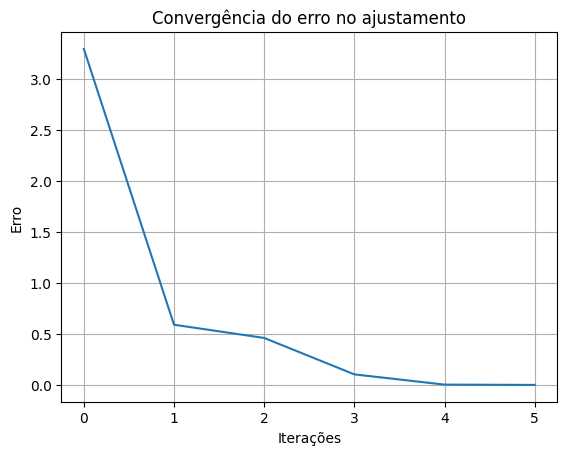

In [40]:
from sympy import symbols, Matrix, sqrt, simplify, diff
import numpy as np
import matplotlib.pyplot as plt

# Valores numéricos para o teste
dados = {"X_1": 1, "Y_1": 3 , "Z_1": 0, 
         "X_b": 2, "Y_b": -1, "Z_b": 0,
         "X_c": 1, "Y_c": -1, "Z_c": 0,
         "theta1": 36.86989765*np.pi/180,
         "theta2": 71.56505117707799*np.pi/180,
         "theta3": 45*np.pi/180}
# X_a = {X_p: 2, Y_p: 1, Z_p: 0} # solucao_esperada ao final do ajustamento

def cos_sin_theta(P, Tn, t):
    # Vetores
    TnP = P - Tn

    # Cosseno do ângulo entre os vetores
    cos_theta = simplify(t.dot(TnP) / (sqrt(t.dot(t)) * sqrt(TnP.dot(TnP))))

    # Seno do ângulo entre os vetores
    cross = t.cross(TnP)
    sen_theta = simplify( sqrt(cross.dot(cross)) / (sqrt(t.dot(t)) * sqrt(TnP.dot(TnP))))

    return cos_theta, sen_theta

# Definindo as variáveis simbólicas
X_b, Y_b, Z_b = symbols('X_b Y_b Z_b')
X_c, Y_c, Z_c = symbols('X_c Y_c Z_c')
X_p, Y_p, Z_p = symbols('X_p Y_p Z_p')
X_1, Y_1, Z_1 = symbols('X_1 Y_1 Z_1')

# Vetores
T1 = Matrix([X_1, Y_1, Z_1])
P = Matrix([X_p, Y_p, Z_p])

b = Matrix([X_b, Y_b, Z_b])
T2 = T1 + b

c = Matrix([X_c, Y_c, Z_c])
T3 = T1 + b + c

f1, f2 = cos_sin_theta(P, T1, b)
f3, f4 = cos_sin_theta(P, T2, -b)
f5, f6 = cos_sin_theta(P, T3, -c)

F = Matrix([[f1],
            [f2],
            [f3],
            [f4],
            [f5],
            [f6]])
# F = F.subs(dados)

# Derivadas parciais
df1_Xp, df1_Yp, df1_Zp = diff(f1, X_p), diff(f1, Y_p), diff(f1, Z_p)
df2_Xp, df2_Yp, df2_Zp = diff(f2, X_p), diff(f2, Y_p), diff(f2, Z_p)
df3_Xp, df3_Yp, df3_Zp = diff(f3, X_p), diff(f3, Y_p), diff(f3, Z_p)
df4_Xp, df4_Yp, df4_Zp = diff(f4, X_p), diff(f4, Y_p), diff(f4, Z_p)
df5_Xp, df5_Yp, df5_Zp = diff(f5, X_p), diff(f5, Y_p), diff(f5, Z_p)
df6_Xp, df6_Yp, df6_Zp = diff(f6, X_p), diff(f6, Y_p), diff(f6, Z_p)

# Montando a matriz Jacobiana
# A = Matrix([[df1_Xp, df1_Yp, df1_Zp],
#             [df2_Xp, df2_Yp, df2_Zp],
#             [df3_Xp, df3_Yp, df3_Zp],
#             [df4_Xp, df4_Yp, df4_Zp],
#             [df5_Xp, df5_Yp, df5_Zp],
#             [df6_Xp, df6_Yp, df6_Zp]]) # 3ª coluna = 0 => não é necessária
A = Matrix([[df1_Xp, df1_Yp],
            [df2_Xp, df2_Yp],
            [df3_Xp, df3_Yp],
            [df4_Xp, df4_Yp],
            [df5_Xp, df5_Yp],
            [df6_Xp, df6_Yp]]) 

### Início do ajustametno 
# Inicializações
# set X0
X_0 = {X_p: 0, Y_p: 0, Z_p: 0} 
print("X0: ", np.array(list(X_0.values())))

# mount Lb
Lb = np.array([[np.cos(dados["theta1"])],
               [np.sin(dados["theta1"])],
               [np.cos(dados["theta2"])],
               [np.sin(dados["theta2"])],
               [np.cos(dados["theta3"])],
               [np.sin(dados["theta3"])]])
values = {**dados, **X_0}

erros = [] # guardar cada erro durante as iterações para compor um gráfico
erro = 10000000
k=1
while erro>10e-6:
    # update L0 = F(X0)
    L0 = np.array(F.subs(values).evalf().tolist(), dtype=float)
    # update L
    L = L0 - Lb
    # update A
    a = np.array(A.subs(values).evalf().tolist(), dtype=float)
    cond_A = np.linalg.cond(a)
    # update X = vetor das correções
    X = -np.linalg.inv(a.T @ a) @ a.T @ L
    # Devido ao corte da 3ª coluna da jacobinana A é necessario adicionar [0]
    # para manter o tamanho do vetor de correções das incógnitas X coerente
    # com o vetor de incógnitas ajustado X_0
    X = np.append(X, [0]) 
    # update erro
    erro = np.linalg.norm(X)
    erros.append(erro)
    # update X0
    X0 = X + np.array(list(X_0.values()))
    print(f"Iter {k}: \tErro: {erro} \t- X0: {X0}\t- Cond(A): {cond_A:.6f}")
    X_0 = {X_p: X0[0], Y_p: X0[1], Z_p: 0} 
    # update lista de valores para a próxima iteração
    values = {**dados, **X_0}
    k+=1

# Gráfico
plt.title("Convergência do erro no ajustamento")
plt.xlabel("Iterações")
plt.ylabel("Erro")
plt.grid()
plt.plot(erros)
plt.show()

**Exercício 4**: O princípio básico de posicionamento GNSS é a trilateração. Suponha que quatro satélites $S$ tem suas coordenadas sendo informadas pelo seu sinal GPS. Através da medição da pseudo-distância, o receptor estima sua distância a cada satélite. Como obter as coordenadas do receptor $P$?


<img src="media/imgs/img12.png" width=600>

$\begin{cases}
d_1 = ||P-S_1|| \ \ \rightarrow (f_1) \\
d_2 = ||P-S_2|| \ \ \rightarrow (f_2) \\
d_3 = ||P-S_3|| \ \ \rightarrow (f_3) \\ 
d_4 = ||P-S_4|| \ \ \rightarrow (f_4) \\ 
\end{cases}$

```python
dados = {"X_1": 0000.0, "Y_1": 5000.0, "Z_1": 4000.0, 
         "X_2": 6000.0, "Y_2": 4000.0, "Z_2": 5000.0,
         "X_3": 7000.0, "Y_3": -3000.0, "Z_3": 3500.0,
         "X_4": -2000.0, "Y_4": -2000.0, "Z_4": 3000.0,
         "d_1": 5724.836, 
         "d_2": 6229.272, 
         "d_3": 6630.869, 
         "d_4": 5914.816, 
        }
```

## Lista de exercícios suplementares

Ghilani, C. D. (2017). *Adjustment computations: Spatial data analysis* (6th ed.). Wiley. 

Pág 219 a 224 (11. PRINCIPLES OF LEAST SQUARES - Problems).


<!-- **Exercício 1 gabarito**
```
import numpy as np

np.set_printoptions(suppress=True,precision=5)

# 0B + 1P - C = 10.013
# B  - 1P - C = 4.985
# B  + 0P - C = 15.004
# B  + 0P - C = 14.996

A = np.array([[0, 1, -1],
              [1, -1, -1],
              [1, 0, -1], 
              [1, 0, -1]])
b = np.array([[10.013], 
              [4.985], 
              [15.004], 
              [14.996]])
X = np.linalg.pinv(A) @ b

A = A[:, :2]  # Considerando apenas as colunas de B e P
X_new = np.linalg.pinv(A) @ b
X, X_new
``` -->

<!-- **Exercício 2 gabarito**

```python
import numpy as np

A = np.array([[1.0, 1.0],
              [1.0, 1.0001],
              [1.0, 0.9999]])

b = np.array([2.0, 
              2.0001,
              1.9999])

cond_A = np.linalg.cond(A)
print("Número de condição de A:", cond_A)

x = np.linalg.pinv(A) @ b  # Solução usando pseudo-inversa
x, np.linalg.inv(A.T @ A) @ A.T @ b``` -->

<!-- **Exercício 04 gabarito** 

```python
import sympy as sp
from sympy import symbols, Matrix, sqrt, simplify, diff
from IPython.display import display

dados = {"X_1": 0000.0, "Y_1": 5000.0, "Z_1": 4000.0, 
         "X_2": 6000.0, "Y_2": 4000.0, "Z_2": 5000.0,
         "X_3": 7000.0, "Y_3": -3000.0, "Z_3": 3500.0,
         "X_4": -2000.0, "Y_4": -2000.0, "Z_4": 3000.0,
         "d_1": 5724.836, 
         "d_2": 6229.272, 
         "d_3": 6630.869, 
         "d_4": 5914.816, 
         }

def norma(A,B):
    return sqrt((A-B).dot(A-B))

# Definindo as variáveis simbólicas
S1 = Matrix([dados["X_1"], dados["Y_1"], dados["Z_1"]])
S2 = Matrix([dados["X_2"], dados["Y_2"], dados["Z_2"]])
S3 = Matrix([dados["X_3"], dados["Y_3"], dados["Z_3"]])
S4 = Matrix([dados["X_4"], dados["Y_4"], dados["Z_4"]])
X_p, Y_p, Z_p = symbols('X_p Y_p Z_p')
P = Matrix([X_p, Y_p, Z_p])

# funções
f1 = norma(P,S1)
f2 = norma(P,S2)
f3 = norma(P,S3)
f4 = norma(P,S4)
F = Matrix([[f1],
            [f2],
            [f3],
            [f4]])
# display(F)

# Derivadas parciais
df1_Xp, df1_Yp, df1_Zp = diff(f1, X_p), diff(f1, Y_p), diff(f1, Z_p)
df2_Xp, df2_Yp, df2_Zp = diff(f2, X_p), diff(f2, Y_p), diff(f2, Z_p)
df3_Xp, df3_Yp, df3_Zp = diff(f3, X_p), diff(f3, Y_p), diff(f3, Z_p)
df4_Xp, df4_Yp, df4_Zp = diff(f4, X_p), diff(f4, Y_p), diff(f4, Z_p)

# Montando a matriz Jacobiana
A = Matrix([[df1_Xp, df1_Yp, df1_Zp],
            [df2_Xp, df2_Yp, df2_Zp],
            [df3_Xp, df3_Yp, df3_Zp],
            [df4_Xp, df4_Yp, df4_Zp]]) 

# Inicialização de X0
X_0 = {X_p: 0.0, Y_p: 0.0, Z_p: 0.0} 

### Início do ajustametno 

# mount Lb
Lb = np.array([[dados["d_1"]],
               [dados["d_2"]],
               [dados["d_3"]],
               [dados["d_4"]]])

values = {**dados, **X_0}

erros = [] # guardar cada erro durante as iterações para compor um gráfico
erro = 10000000
k = 0
while erro>10e-6:
    # update L0 = F(X0)
    L0 = np.array(F.subs(values).evalf().tolist(), dtype=float)
    # update L
    L = L0 - Lb
    # update A
    a = np.array(A.subs(values).evalf().tolist(), dtype=float)
    # update X = vetor das correções
    DeltaX = -np.linalg.inv(a.T @ a) @ a.T @ L
    DeltaX = DeltaX.reshape(-1) # reshape para converter de matriz coluna para vetor
    # update erro
    erro = np.linalg.norm(DeltaX)
    erros.append(erro)
    # update X0
    X0 = DeltaX + np.array(list(X_0.values()))
    # print("\nXa:\n", X0)
    X_0 = {X_p: X0[0], Y_p: X0[1], Z_p: X0[2]} 
    print(f"Iter {k}: \tErro: {erro} \t- X0: {X0}")
    # update lista de valores para a próxima iteração
    values = {**dados, **X_0}
    k+=1

# Gráfico
plt.title("Convergência do erro no ajustamento")
plt.xlabel("Iterações")
plt.ylabel("Erro")
plt.grid()
plt.plot(erros)
plt.show()``` -->